In [1]:
import numpy as np
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns

import matplotlib.pyplot as plt


from pylab import *
import seaborn as sn 
from sklearn import model_selection
import statsmodels.api as sm
from datetime import datetime
from sklearn.decomposition import PCA

import warnings; warnings.simplefilter('ignore')

plt.style.use('fivethirtyeight')

from SSA2 import SSAv3


%matplotlib inline

In [2]:
data = pd.read_csv('105v2.csv', parse_dates=True, index_col='DateTime',encoding="windows-1252") # или 106.csv
data.head(5)

,AffinityIndex,SerialNumber,H,Tmean,WmeanH,WindDirectionH(Â°),WminH,WmaxH,WmeanV,AtmosphericPressure,RelativeHumidity,TdewPoint(Â°C),WaterVaporElasticity,AbsolutusHumidity,DensityofAir,SpeedofSoundinAir
DateTime,,,,,,,,,,,,,,,,
2017-07-22 00:01:00,6,12427AMK-03,15,15.86,0.20,94.53,0.01,0.44,-0.13,750.45,100.0,15.86,17.99,14.53,1.1954,342.12
2017-07-22 00:02:00,6,12427AMK-03,15,15.88,0.28,104.28,0.15,0.53,-0.19,750.45,100.0,15.88,18.01,14.55,1.1953,342.14
2017-07-22 00:03:00,6,12427AMK-03,15,15.87,0.23,68.53,0.11,0.36,-0.19,750.45,100.0,15.87,17.99,14.54,1.1954,342.13
2017-07-22 00:04:00,6,12427AMK-03,15,15.95,0.17,47.04,0.01,0.33,-0.18,750.45,100.0,15.95,18.09,14.62,1.1950,342.18
2017-07-22 00:05:00,6,12427AMK-03,15,16.01,0.06,11.99,0.01,0.22,-0.19,750.45,100.0,16.01,18.16,14.68,1.1947,342.22


In [3]:
data.info()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1186390 entries, 2017-07-22 00:01:00 to 2020-04-09 23:59:00
Data columns (total 16 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   AffinityIndex         1186390 non-null  int64  
 1   SerialNumber          1186390 non-null  object 
 2   H                     1186390 non-null  int64  
 3   Tmean                 1186390 non-null  float64
 4   WmeanH                1186390 non-null  float64
 5   WindDirectionH(Â°)    1186390 non-null  float64
 6   WminH                 1186390 non-null  float64
 7   WmaxH                 1186390 non-null  float64
 8   WmeanV                1186390 non-null  float64
 9   AtmosphericPressure   1186390 non-null  float64
 10  RelativeHumidity      1186390 non-null  float64
 11  TdewPoint(Â°C)        1186390 non-null  float64
 12  WaterVaporElasticity  1186390 non-null  float64
 13  AbsolutusHumidity     1186390 non-null  float64
 14  D

In [4]:
del data['AffinityIndex'] 
del data['SerialNumber'] 
del data['H'] 
del data['WminH'] 
del data['WmaxH'] 
del data['WindDirectionH(Â°)'] 
del data['TdewPoint(Â°C)'] 
del data['WaterVaporElasticity'] 
del data['AbsolutusHumidity'] 
del data['DensityofAir'] 
del data['SpeedofSoundinAir'] 

In [5]:
data = data.groupby(pd.Grouper(freq='D')).mean()  # ПЕРИОД
data

,Tmean,WmeanH,WmeanV,AtmosphericPressure,RelativeHumidity
DateTime,,,,,
2017-07-22,19.476312,1.202660,-0.122234,750.230475,77.639915
2017-07-23,20.851142,1.164227,0.055816,749.047753,68.623974
2017-07-24,20.588375,1.556807,0.220068,746.373318,77.926284
2017-07-25,21.122393,2.011374,0.133744,742.115037,77.207245
2017-07-26,21.097521,1.113449,-0.164357,744.684319,80.063233
...,...,...,...,...,...
2020-04-05,5.206268,2.944479,1.023910,761.228300,28.456948
2020-04-06,6.587525,1.797609,0.383534,752.998987,41.198309
2020-04-07,7.605675,2.314117,0.821881,752.539291,52.011658


In [6]:
data.interpolate(method='linear', inplace=True)


In [7]:
per_temp2 = data['Tmean']  #24     48

display(per_temp2.head(5))
display(per_temp2.tail(5))

DateTime
2017-07-22    19.476312
2017-07-23    20.851142
2017-07-24    20.588375
2017-07-25    21.122393
2017-07-26    21.097521
Freq: D, Name: Tmean, dtype: float64

DateTime
2020-04-05    5.206268
2020-04-06    6.587525
2020-04-07    7.605675
2020-04-08    3.743463
2020-04-09    2.579199
Freq: D, Name: Tmean, dtype: float64

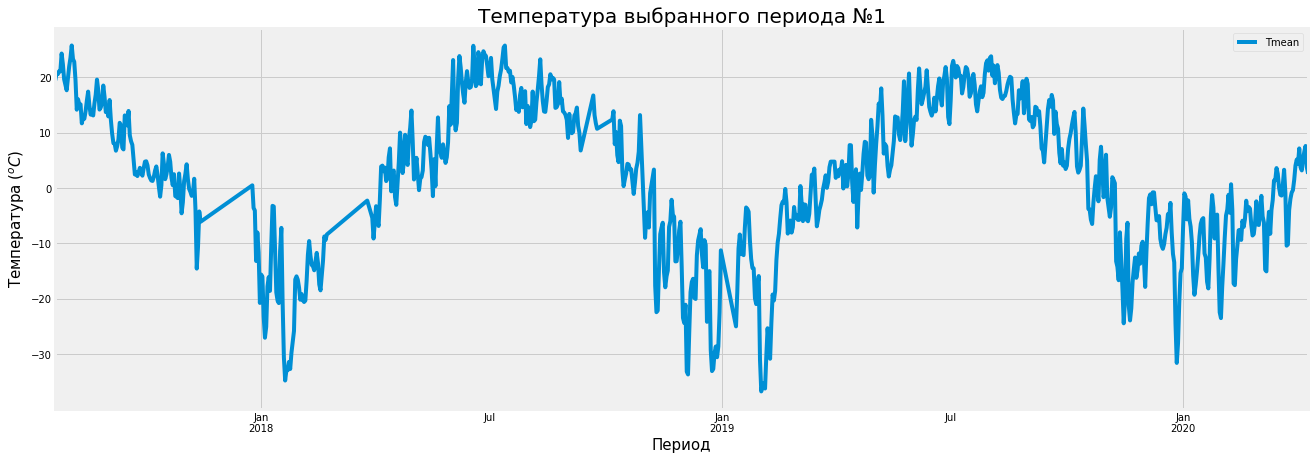

In [8]:
plt.figure()
per_temp2.plot(figsize=[20,7])
#per_temp2.plot(style='k.')
plt.title('Температура выбранного периода №1', fontsize=20)
plt.grid(True)
plt.ylabel('Температура ($^oC$)',fontsize=15)
plt.xlabel('Период',fontsize=15)
plt.legend()

In [9]:
data.shape


(993, 5)

In [10]:
data.describe()


,Tmean,WmeanH,WmeanV,AtmosphericPressure,RelativeHumidity
count,993.000000,993.000000,993.000000,993.000000,993.000000
mean,1.603665,2.016563,0.105094,754.102570,79.489580
std,13.288481,0.932163,0.615439,9.147010,18.666694
min,-36.777014,0.554354,-2.074493,731.943535,19.370581
25%,-6.294299,1.351167,-0.131252,747.690565,66.570462
50%,2.080542,1.893721,0.008286,752.956846,83.644805
75%,12.840903,2.460851,0.182562,759.240213,96.780940
max,25.782513,6.169168,6.216539,828.850000,101.099046


In [11]:
data

,Tmean,WmeanH,WmeanV,AtmosphericPressure,RelativeHumidity
DateTime,,,,,
2017-07-22,19.476312,1.202660,-0.122234,750.230475,77.639915
2017-07-23,20.851142,1.164227,0.055816,749.047753,68.623974
2017-07-24,20.588375,1.556807,0.220068,746.373318,77.926284
2017-07-25,21.122393,2.011374,0.133744,742.115037,77.207245
2017-07-26,21.097521,1.113449,-0.164357,744.684319,80.063233
...,...,...,...,...,...
2020-04-05,5.206268,2.944479,1.023910,761.228300,28.456948
2020-04-06,6.587525,1.797609,0.383534,752.998987,41.198309
2020-04-07,7.605675,2.314117,0.821881,752.539291,52.011658


In [12]:
# data_correlation = data[['Tmean', 'WmeanH', 'WmeanV', 'AtmosphericPressure', 'RelativeHumidity']].corr()
# mask = np.array(data_correlation)
# # Try numpy.triu (triangle-upper) and numpy.tril (triangle-lower)
# mask[np.tril_indices_from(mask)] = False
# fig = plt.subplots(figsize=(20,10))
# sn.heatmap(data_correlation, mask=mask, vmax=1, square=True, annot=True)

# yt

In [13]:
# pca = PCA(n_components=2)
# pca.fit(data)

In [14]:
# existing_2d = pca.transform(data)
# existing_df_2d = pd.DataFrame(existing_2d)
# existing_df_2d.index = data.index
# existing_df_2d.columns = ['PC1','PC2']
# existing_df_2d.head()

In [15]:
# print (pca.explained_variance_ratio_)

# yt

In [16]:
# data = data.drop(['WmeanH', 'WmeanV', 'RelativeHumidity'], axis=1)


In [17]:
# fig, (ax1) = plt.subplots(figsize=(20,5))
# sn.regplot(x=data['AtmosphericPressure'], y=data['Tmean'], ax=ax1)
# ax1.set(title="Relation between Tmean and AtmosphericPressure")

In [18]:
# from sklearn import decomposition

# # Plot PCA spectrum
# pca = decomposition.PCA()
# pca.fit(data)

# plt.figure(1, figsize=(10, 10))
# plt.plot(pca.explained_variance_, linewidth=2)
# plt.axis('tight')
# plt.xlabel('Number of components')
# plt.ylabel('Explained variance')

In [19]:
model = PCA()


In [21]:
model.fit(data.iloc[:,0:4])


PCA(copy=True, iterated_power='auto', n_components=None, random_state=None,
    svd_solver='auto', tol=0.0, whiten=False)

In [22]:

mean = model.mean_
mean

array([1.60366454e+00, 2.01656350e+00, 1.05094332e-01, 7.54102570e+02])

In [23]:
first_pc = model.components_[0,:]
first_pc

array([-8.72362693e-01,  5.38080477e-03,  3.21984952e-04,  4.88829496e-01])

In [25]:
transformed = model.transform(data.iloc[:,0:4])


In [26]:
print(transformed)


[[-1.74886778e+01  5.38946299e+00 -4.88335934e-01  1.14719798e-02]
 [-1.92663269e+01  5.03097415e+00 -4.54600174e-01  1.91691216e-01]
 [-2.03422763e+01  2.55166052e+00 -1.42210146e-01  2.13918868e-01]
 ...
 [-5.99827496e+00  1.54846627e+00  6.81766898e-01  4.77947101e-01]
 [-1.47871593e+00  1.67553168e+00  1.07924540e+00 -2.19120650e-01]
 [ 2.86051363e+00  7.09175873e+00  3.37240562e-01 -1.05532943e-01]]


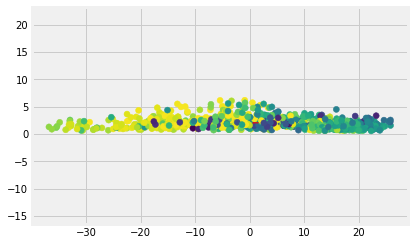

In [28]:
plt.scatter(data.iloc[:,0], data.iloc[:,1], c = data.iloc[:,-1])
plt.arrow(mean[0], mean[1], first_pc[0], first_pc[1], color='red', width=0.05)
plt.axis('equal')
plt.show()

In [29]:
features = range(model.n_components_)
features

range(0, 4)

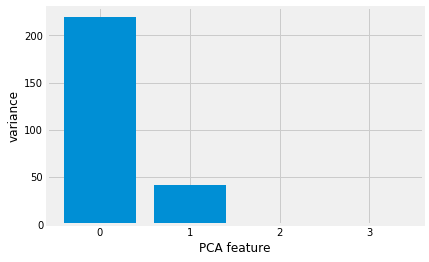

In [30]:
plt.bar(features, model.explained_variance_)
plt.xticks(features)
plt.ylabel('variance')
plt.xlabel('PCA feature')
plt.show()

In [32]:
# Create a PCA model with 2 components: pca
pca = PCA(n_components = 2)

# Fit the PCA instance to the scaled samples
pca.fit(data.iloc[:,0:4])

# Transform the scaled samples: pca_features
pca_features = pca.transform(data.iloc[:,0:4])

# Print the shape of pca_features
print(pca_features.shape)

(993, 2)


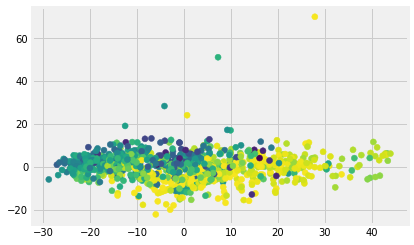

In [34]:
xs = pca_features[:,0]
ys = pca_features[:,1]

plt.scatter(xs, ys, c = data.iloc[:,-1])
plt.show()